<a href="https://colab.research.google.com/github/snehalhavale22-wq/Snehal/blob/main/Activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv('/content/sample_data/california_housing_test.csv')

print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.05     37.37                27.0       3885.0           661.0   
1    -118.30     34.26                43.0       1510.0           310.0   
2    -117.81     33.78                27.0       3589.0           507.0   
3    -118.36     33.82                28.0         67.0            15.0   
4    -119.67     36.33                19.0       1241.0           244.0   

   population  households  median_income  median_house_value  
0      1537.0       606.0         6.6085            344700.0  
1       809.0       277.0         3.5990            176500.0  
2      1484.0       495.0         5.7934            270500.0  
3        49.0        11.0         6.1359            330000.0  
4       850.0       237.0         2.9375             81700.0  


In [ ]:
print(df.info())

print(df.describe())

print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   float64
 3   total_rooms         3000 non-null   float64
 4   total_bedrooms      3000 non-null   float64
 5   population          3000 non-null   float64
 6   households          3000 non-null   float64
 7   median_income       3000 non-null   float64
 8   median_house_value  3000 non-null   float64
dtypes: float64(9)
memory usage: 211.1 KB
None
         longitude    latitude  housing_median_age   total_rooms  \
count  3000.000000  3000.00000         3000.000000   3000.000000   
mean   -119.589200    35.63539           28.845333   2599.578667   
std       1.994936     2.12967           12.555396   2155.593332   
min    -124.180000    32.56000      

In [ ]:
print(df.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


In [ ]:
df = df.fillna(df.mean(numeric_only=True))

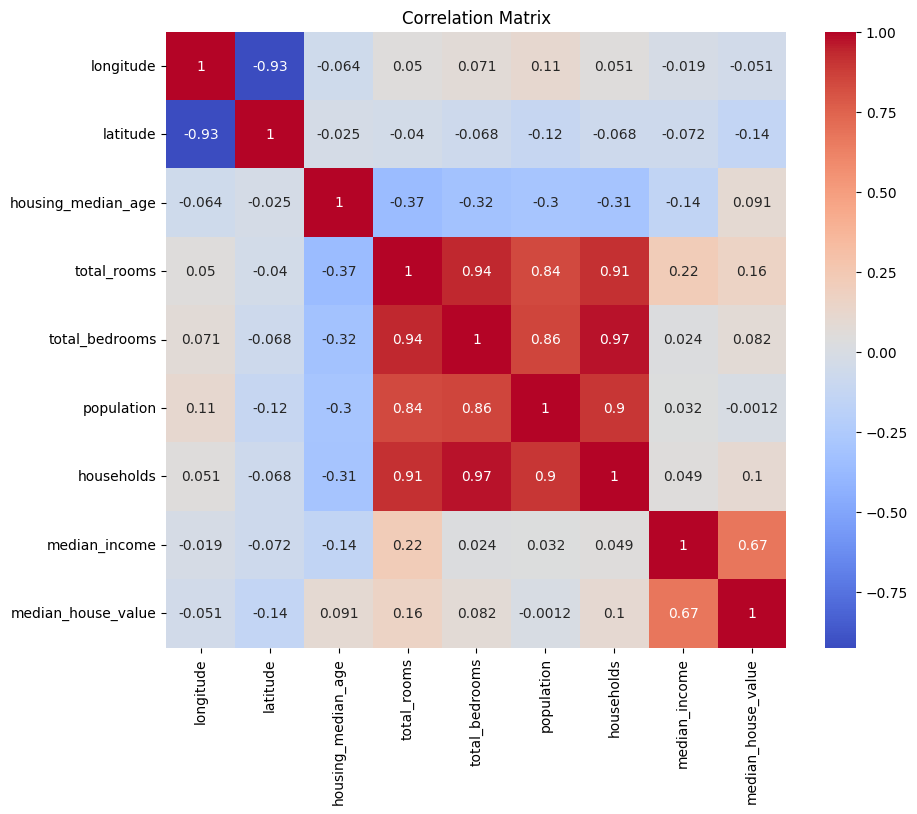

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

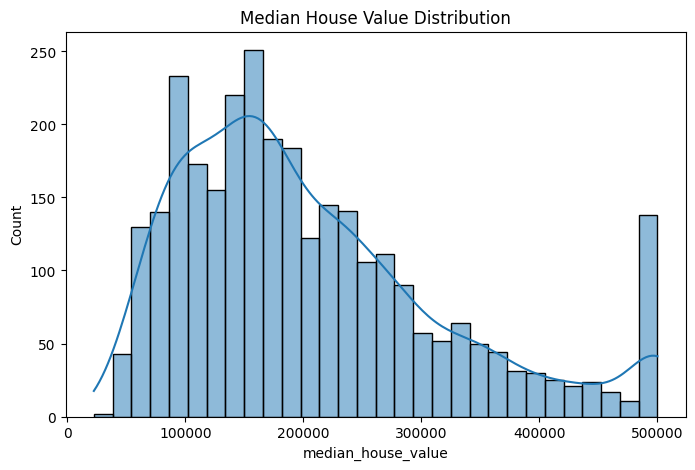

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['median_house_value'], bins=30, kde=True)
plt.title("Median House Value Distribution")
plt.show()

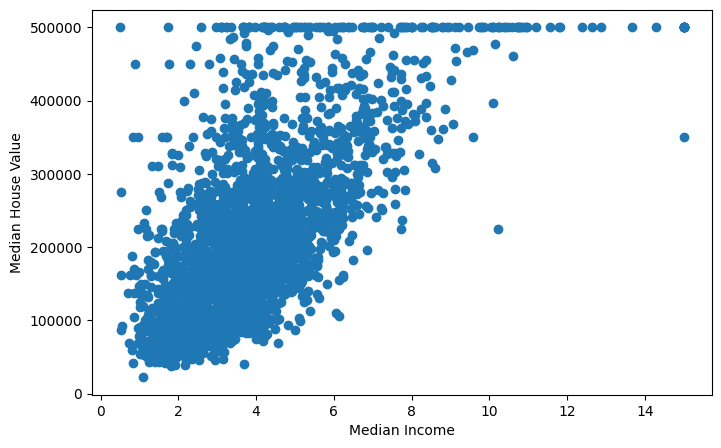

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['median_income'], df['median_house_value'])
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

In [ ]:
X = df.drop('median_house_value', axis=1)

y = df['median_house_value']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 49554.27620826821


In [ ]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 4586505886.68125


In [ ]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 67723.74684467222


In [ ]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.6358044169850408


In [ ]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(results.head(10))

        Actual      Predicted
1801  119400.0  126565.069443
1190  133600.0  145859.800832
1817  173600.0  247176.001173
251   218600.0  207110.679931
2505  276700.0  194794.790395
1117  146800.0  175428.699974
1411  166300.0  229747.207280
2113  197200.0  163606.508357
408   162500.0   69564.074478
2579  287800.0  197037.575346


In [ ]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(results.head(10))

        Actual      Predicted
1801  119400.0  126565.069443
1190  133600.0  145859.800832
1817  173600.0  247176.001173
251   218600.0  207110.679931
2505  276700.0  194794.790395
1117  146800.0  175428.699974
1411  166300.0  229747.207280
2113  197200.0  163606.508357
408   162500.0   69564.074478
2579  287800.0  197037.575346


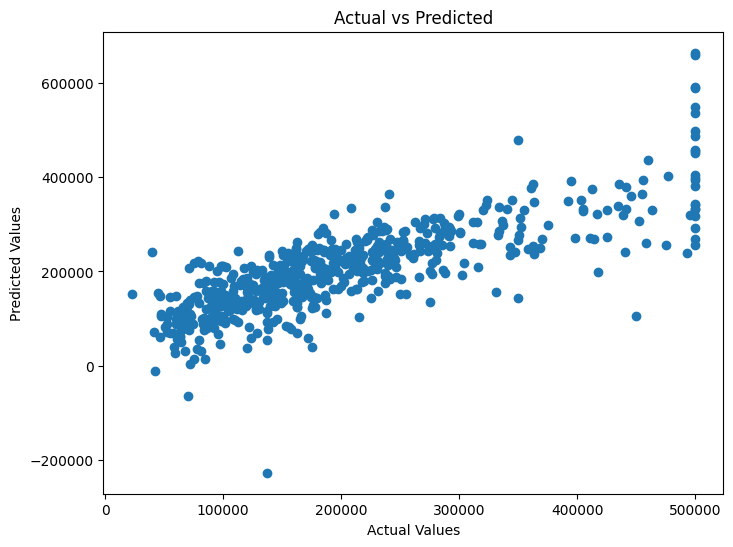

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

plt.show()

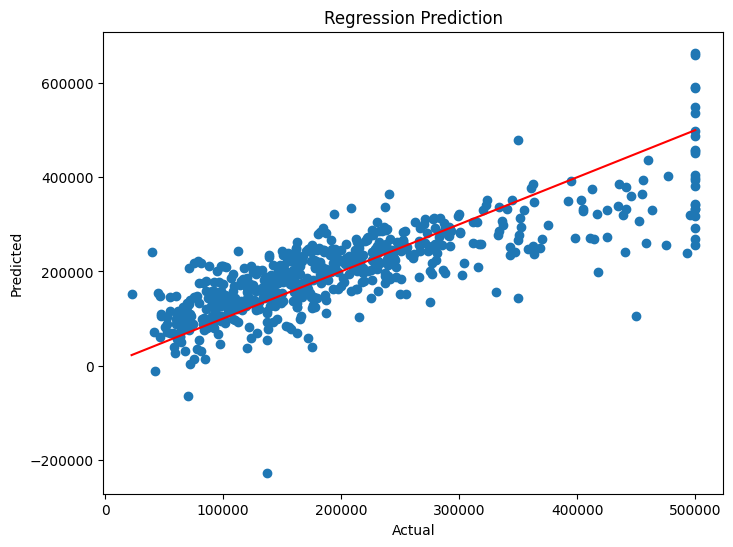

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Regression Prediction")

plt.show()

In [ ]:
new_data = X.iloc[[0]]

prediction = model.predict(new_data)

print("Predicted House Value:", prediction[0])

Predicted House Value: 352698.2361933137


Perform processing and feature preparation


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [ ]:
df = pd.read_csv('/content/sample_data/california_housing_test.csv')

print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.05     37.37                27.0       3885.0           661.0   
1    -118.30     34.26                43.0       1510.0           310.0   
2    -117.81     33.78                27.0       3589.0           507.0   
3    -118.36     33.82                28.0         67.0            15.0   
4    -119.67     36.33                19.0       1241.0           244.0   

   population  households  median_income  median_house_value  
0      1537.0       606.0         6.6085            344700.0  
1       809.0       277.0         3.5990            176500.0  
2      1484.0       495.0         5.7934            270500.0  
3        49.0        11.0         6.1359            330000.0  
4       850.0       237.0         2.9375             81700.0  


In [ ]:
print("First 5 Rows")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

First 5 Rows
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.05     37.37                27.0       3885.0           661.0   
1    -118.30     34.26                43.0       1510.0           310.0   
2    -117.81     33.78                27.0       3589.0           507.0   
3    -118.36     33.82                28.0         67.0            15.0   
4    -119.67     36.33                19.0       1241.0           244.0   

   population  households  median_income  median_house_value  
0      1537.0       606.0         6.6085            344700.0  
1       809.0       277.0         3.5990            176500.0  
2      1484.0       495.0         5.7934            270500.0  
3        49.0        11.0         6.1359            330000.0  
4       850.0       237.0         2.9375             81700.0  

Dataset Shape:
(3000, 9)


In [ ]:
print("\nDataset Information")
print(df.info())


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   float64
 3   total_rooms         3000 non-null   float64
 4   total_bedrooms      3000 non-null   float64
 5   population          3000 non-null   float64
 6   households          3000 non-null   float64
 7   median_income       3000 non-null   float64
 8   median_house_value  3000 non-null   float64
dtypes: float64(9)
memory usage: 211.1 KB
None


In [ ]:
print("\nSummary Statistics")
print(df.describe())


Summary Statistics
         longitude    latitude  housing_median_age   total_rooms  \
count  3000.000000  3000.00000         3000.000000   3000.000000   
mean   -119.589200    35.63539           28.845333   2599.578667   
std       1.994936     2.12967           12.555396   2155.593332   
min    -124.180000    32.56000            1.000000      6.000000   
25%    -121.810000    33.93000           18.000000   1401.000000   
50%    -118.485000    34.27000           29.000000   2106.000000   
75%    -118.020000    37.69000           37.000000   3129.000000   
max    -114.490000    41.92000           52.000000  30450.000000   

       total_bedrooms    population  households  median_income  \
count     3000.000000   3000.000000  3000.00000    3000.000000   
mean       529.950667   1402.798667   489.91200       3.807272   
std        415.654368   1030.543012   365.42271       1.854512   
min          2.000000      5.000000     2.00000       0.499900   
25%        291.000000    780.000000  

In [ ]:
print("\nMissing Values")
print(df.isnull().sum())

# If any missing values exist, fill them with column mean
df = df.fillna(df.mean(numeric_only=True))



Missing Values
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


In [ ]:
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()



Duplicate Rows: 0


In [ ]:
# Target Variable
y = df['median_house_value']

# Features
X = df.drop('median_house_value', axis=1)

print("\nFeatures")
print(X.columns)



Features
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled Features Shape:")
print(X_scaled.shape)


Scaled Features Shape:
(3000, 8)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Set Shape")
print(X_train.shape)

print("Testing Set Shape")
print(X_test.shape)



Training Set Shape
(2400, 8)
Testing Set Shape
(600, 8)


In [ ]:
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

print("\nProcessed Training Data")
print(X_train.head())



Processed Training Data
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0   0.636317 -0.725769           -0.067340    -0.197927        0.695524   
1   0.566127 -0.688198           -0.385981     0.099489        0.349024   
2   0.866939 -0.899534            0.171641    -0.652170       -0.560537   
3   0.726560 -0.753947            0.729264    -0.534781       -0.570162   
4  -1.414216  0.927345            1.366546     0.174191        0.272025   

   population  households  median_income  
0    1.111445    0.747445      -1.039947  
1    0.058427    0.356053       0.205063  
2    0.193330   -0.503370      -0.794936  
3   -0.350164   -0.563584       0.178097  
4    0.073955    0.238361       0.007620  


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv('/content/sample_data/california_housing_test.csv')

print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.05     37.37                27.0       3885.0           661.0   
1    -118.30     34.26                43.0       1510.0           310.0   
2    -117.81     33.78                27.0       3589.0           507.0   
3    -118.36     33.82                28.0         67.0            15.0   
4    -119.67     36.33                19.0       1241.0           244.0   

   population  households  median_income  median_house_value  
0      1537.0       606.0         6.6085            344700.0  
1       809.0       277.0         3.5990            176500.0  
2      1484.0       495.0         5.7934            270500.0  
3        49.0        11.0         6.1359            330000.0  
4       850.0       237.0         2.9375             81700.0  


In [4]:
print(df.head())

print(df.shape)

print(df.info())

print(df.describe())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.05     37.37                27.0       3885.0           661.0   
1    -118.30     34.26                43.0       1510.0           310.0   
2    -117.81     33.78                27.0       3589.0           507.0   
3    -118.36     33.82                28.0         67.0            15.0   
4    -119.67     36.33                19.0       1241.0           244.0   

   population  households  median_income  median_house_value  
0      1537.0       606.0         6.6085            344700.0  
1       809.0       277.0         3.5990            176500.0  
2      1484.0       495.0         5.7934            270500.0  
3        49.0        11.0         6.1359            330000.0  
4       850.0       237.0         2.9375             81700.0  
(3000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  -

In [5]:
print(df.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


In [6]:
df = df.fillna(df.mean(numeric_only=True))

In [7]:
X = df.drop('median_house_value', axis=1)

y = df['median_house_value']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [10]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [12]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 49554.276208268304
MSE : 4586505886.68125
RMSE : 67723.74684467222
R2 Score : 0.6358044169850408


In [13]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(10))

     Actual      Predicted
0  119400.0  126565.069443
1  133600.0  145859.800832
2  173600.0  247176.001173
3  218600.0  207110.679931
4  276700.0  194794.790395
5  146800.0  175428.699974
6  166300.0  229747.207280
7  197200.0  163606.508357
8  162500.0   69564.074478
9  287800.0  197037.575346


In [14]:
median = df['median_house_value'].median()

df['Price_Class'] = np.where(
    df['median_house_value'] >= median,
    1,
    0
)

In [15]:
X = df.drop(['median_house_value', 'Price_Class'], axis=1)

y = df['Price_Class']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [18]:
classifier = LogisticRegression()

classifier.fit(X_train, y_train)

LogisticRegression()

In [19]:
classifier = LogisticRegression()

classifier.fit(X_train, y_train)

LogisticRegression()

In [21]:
y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix")

print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")

print(classification_report(y_test, y_pred))

Accuracy: 0.8283333333333334

Confusion Matrix
[[259  51]
 [ 52 238]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.84      0.83       310
           1       0.82      0.82      0.82       290

    accuracy                           0.83       600
   macro avg       0.83      0.83      0.83       600
weighted avg       0.83      0.83      0.83       600



In [22]:
sample = X.iloc[[0]]

sample = scaler.transform(sample)

prediction = classifier.predict(sample)

print("Predicted Class:", prediction[0])

Predicted Class: 1


Predective output anr performance

In [23]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [24]:
df = pd.read_csv('/content/sample_data/california_housing_test.csv')

print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.05     37.37                27.0       3885.0           661.0   
1    -118.30     34.26                43.0       1510.0           310.0   
2    -117.81     33.78                27.0       3589.0           507.0   
3    -118.36     33.82                28.0         67.0            15.0   
4    -119.67     36.33                19.0       1241.0           244.0   

   population  households  median_income  median_house_value  
0      1537.0       606.0         6.6085            344700.0  
1       809.0       277.0         3.5990            176500.0  
2      1484.0       495.0         5.7934            270500.0  
3        49.0        11.0         6.1359            330000.0  
4       850.0       237.0         2.9375             81700.0  


In [25]:
X = df.drop('median_house_value', axis=1)

y = df['median_house_value']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [28]:
y_pred = model.predict(X_test)

In [29]:
prediction = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

prediction.head(10)

,Actual Price,Predicted Price
1801,119400.0,126565.069443
1190,133600.0,145859.800832
1817,173600.0,247176.001173
251,218600.0,207110.679931
2505,276700.0,194794.790395
1117,146800.0,175428.699974
1411,166300.0,229747.207280
2113,197200.0,163606.508357
408,162500.0,69564.074478
2579,287800.0,197037.575346


In [30]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 49554.27620826821


In [31]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 4586505886.68125


In [32]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 67723.74684467222


In [33]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.6358044169850408


In [34]:
print("========== Model Performance ==========")

print("MAE :", mean_absolute_error(y_test, y_pred))

print("MSE :", mean_squared_error(y_test, y_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score :", r2_score(y_test, y_pred))

========== Model Performance ==========
MAE : 49554.27620826821
MSE : 4586505886.68125
RMSE : 67723.74684467222
R2 Score : 0.6358044169850408


In [35]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison.head(20)

,Actual,Predicted
0,119400.0,126565.069443
1,133600.0,145859.800832
2,173600.0,247176.001173
3,218600.0,207110.679931
4,276700.0,194794.790395
5,146800.0,175428.699974
6,166300.0,229747.207280
7,197200.0,163606.508357
8,162500.0,69564.074478
9,287800.0,197037.575346


In [36]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

print("Predicted House Value:", prediction[0])

Predicted House Value: 352698.2361933137


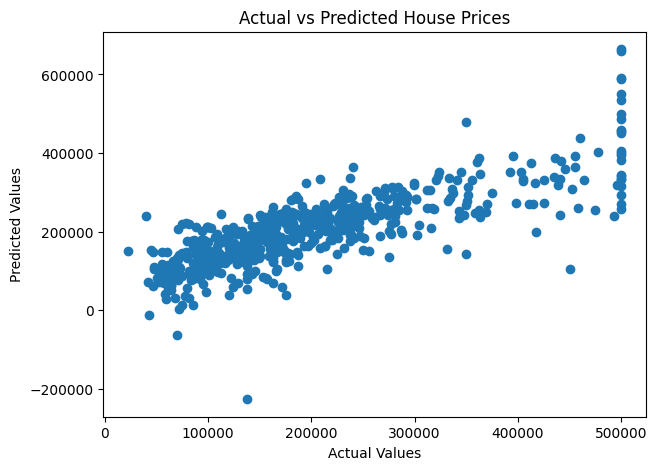

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted House Prices")

plt.show()

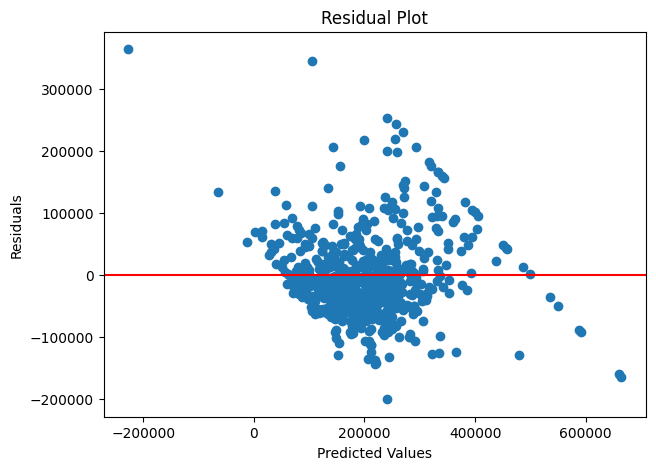

In [38]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()